In [1]:
from roboflow import Roboflow
import os
import shutil
import random
import yaml

# 1. Download Dataset
# rf = Roboflow(api_key="9X8ClVkM9agUJAH3hcAN")
# project = rf.workspace("hard-drive").project("hdd_global_scout")
# version = project.version(3)
# dataset = version.download("yolov8")

rf = Roboflow(api_key="9X8ClVkM9agUJAH3hcAN")
project = rf.workspace("hard-drive").project("electronic_device_global")
version = project.version(1)
dataset = version.download("yolov8")
                
DATA_PATH = dataset.location
OUTPUT_DIR = "dataset_rfdetr_box_1080"

# 2. Create directory structure
for split in ['train', 'valid', 'test']:
    os.makedirs(os.path.join(OUTPUT_DIR, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, split, 'labels'), exist_ok=True)

images_dir = os.path.join(DATA_PATH, "train", "images")
labels_dir = os.path.join(DATA_PATH, "train", "labels")

# 3. Shuffle and split (80% Train, 10% Val, 10% Test)
images = [f for f in os.listdir(images_dir) if f.endswith('.jpg')]
random.seed(42)
random.shuffle(images)

train_idx, val_idx = int(len(images) * 0.8), int(len(images) * 0.9)
splits = {'train': images[:train_idx], 'valid': images[train_idx:val_idx], 'test': images[val_idx:]}

# 4. Convert Polygons to Bounding Boxes
for split_name, img_list in splits.items():
    for img_name in img_list:
        # Copy Image
        shutil.copy(os.path.join(images_dir, img_name), os.path.join(OUTPUT_DIR, split_name, 'images', img_name))
        
        # Clean and Copy Label
        label_name = img_name.replace('.jpg', '.txt')
        label_src = os.path.join(labels_dir, label_name)
        label_dest = os.path.join(OUTPUT_DIR, split_name, 'labels', label_name)
        
        if os.path.exists(label_src):
            with open(label_src, 'r') as f_in:
                lines = f_in.readlines()
            
            cleaned_lines = []
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_id = parts[0]
                    # Extract all polygon coordinates
                    coords = [float(p) for p in parts[1:]]
                    
                    # Separate X and Y coordinates
                    x_coords = coords[0::2]
                    y_coords = coords[1::2]
                    
                    # Calculate the bounding box that wraps the polygon
                    min_x, max_x = min(x_coords), max(x_coords)
                    min_y, max_y = min(y_coords), max(y_coords)
                    
                    cx = (min_x + max_x) / 2.0
                    cy = (min_y + max_y) / 2.0
                    w = max_x - min_x
                    h = max_y - min_y
                    
                    # Format exactly as YOLO Bounding Box: class cx cy w h
                    cleaned_lines.append(f"{class_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
            
            with open(label_dest, 'w') as f_out:
                f_out.write("\n".join(cleaned_lines) + "\n")

# 5. Fix data.yaml paths for RF-DETR
with open(os.path.join(DATA_PATH, 'data.yaml'), 'r') as f:
    data_yaml = yaml.safe_load(f)

data_yaml['train'] = 'train/images'
data_yaml['val'] = 'valid/images'
data_yaml['test'] = 'test/images'

with open(os.path.join(OUTPUT_DIR, 'data.yaml'), 'w') as f:
    yaml.dump(data_yaml, f)

print(f"✅ Dataset split! Polygons successfully converted to Bounding Boxes in {OUTPUT_DIR}/")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Electronic_Device_Global-1 in yolov8:: 100%|██████████| 5603/5603 [00:00<00:00, 8623.22it/s]


✅ Dataset split! Polygons successfully converted to Bounding Boxes in dataset_rfdetr_box_1080/


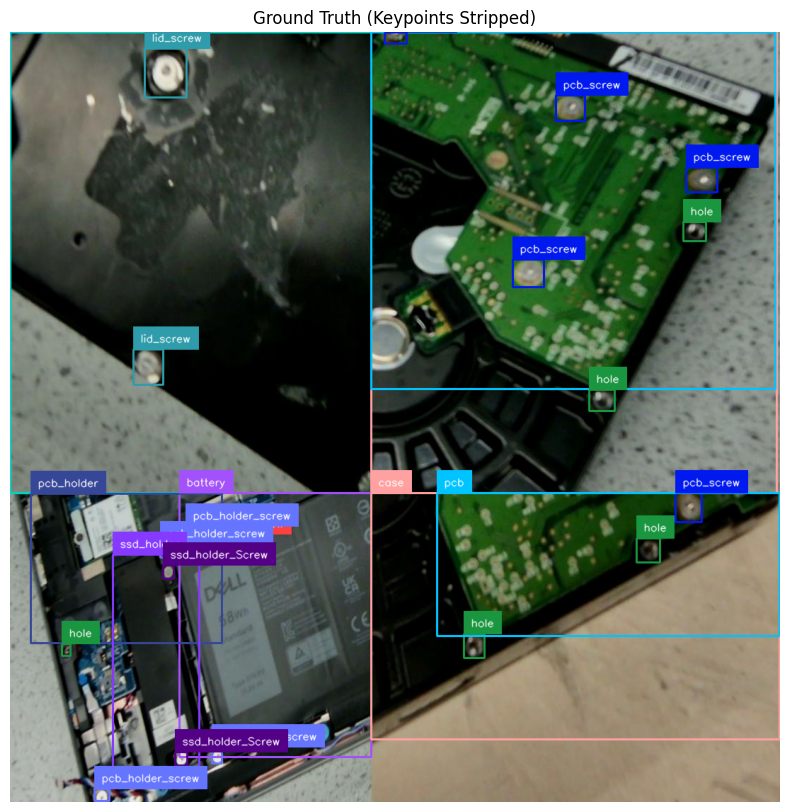

In [2]:
import supervision as sv
import cv2
import matplotlib.pyplot as plt

# Load dataset into Supervision to verify the bounding boxes are clean
dataset = sv.DetectionDataset.from_yolo(
    images_directory_path=os.path.join(OUTPUT_DIR, 'train', 'images'),
    annotations_directory_path=os.path.join(OUTPUT_DIR, 'train', 'labels'),
    data_yaml_path=os.path.join(OUTPUT_DIR, 'data.yaml')
)

image_name, image, annotations = dataset[0]

# Setup Box Annotator
box_annotator = sv.BoxAnnotator(thickness=2)
label_annotator = sv.LabelAnnotator()

with open(os.path.join(OUTPUT_DIR, 'data.yaml'), 'r') as f:
    classes = yaml.safe_load(f)['names']

labels = [classes[class_id] for class_id in annotations.class_id]

# Apply Annotations
annotated_image = box_annotator.annotate(scene=image.copy(), detections=annotations)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=annotations, labels=labels)

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Ground Truth (Keypoints Stripped)")
plt.show()

In [4]:
from rfdetr import RFDETRLarge

# Initialize the pure detection variant
model = RFDETRLarge()
RUN_DIR = "runs/train/rfdetr_box_1088" # Updated folder name

# Train the model
model.train(
    dataset_dir=OUTPUT_DIR,
    output_dir=RUN_DIR,
    epochs=100,
    batch_size=8,          # Safe for 8GB VRAM
    grad_accum_steps=2,    # Simulates a batch size of 16 (2 * 8) for stability
    num_workers=8,
    resolution=1088        # The AI-safe equivalent of 1080
)

[2026-05-04 17:37:02] [INFO] rf-detr - File rf-detr-large-2026.pth already exists with correct MD5 hash.


[2026-05-04 17:37:02] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-05-04 17:37:02] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-05-04 17:37:02] [INFO] rf-detr - File rf-detr-large-2026.pth already exists with correct MD5 hash.


[2026-05-04 17:37:02] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-05-04 17:37:02] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-05-04 17:37:03] [INFO] rf-detr - File rf-detr-large-2026.pth already exists with correct MD5 hash.


[2026-05-04 17:37:03] [WARNING] rf-detr - Checkpoint has 90 classes but model is configured for 18. The detection head will be re-initialized to 18 classes.


RuntimeError: Error(s) in loading state_dict for LWDETR:
	size mismatch for backbone.0.encoder.encoder.embeddings.position_embeddings: copying a param with shape torch.Size([1, 1937, 384]) from checkpoint, the shape in current model is torch.Size([1, 4625, 384]).

In [ ]:
import json
import pandas as pd
import os

RUN_DIR = "runs/train/rfdetr_box_1088"
log_file = os.path.join(RUN_DIR, 'log.txt')

if os.path.exists(log_file):
    records = []
    with open(log_file, 'r') as f:
        for line in f:
            try:
                # RF-DETR writes each epoch's stats as a JSON line
                records.append(json.loads(line.strip()))
            except json.JSONDecodeError:
                continue # Skip non-JSON lines

    df = pd.DataFrame(records)
    
    # In standard DETR architectures, the mAP metrics are stored in a list 
    # under the key 'test_coco_eval_bbox'. The first item is mAP 50-95.
    if 'test_coco_eval_bbox' in df.columns:
        # Extract the first element (mAP 0.5:0.95) from the evaluation array
        best_box_map = df['test_coco_eval_bbox'].dropna().apply(lambda x: x[0]).max()
        print(f"🏆 Best Bounding Box mAP (50-95): {best_box_map:.4f}")
    else:
        # Fallback just in case the keys are named differently
        print("Metrics loaded successfully! Available columns:")
        print(df.columns.tolist())
else:
    print("❌ log.txt file not found. Ensure training completed.")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

RUN_DIR = "runs/train/rfdetr_box_1088"
plot_path = os.path.join(RUN_DIR, 'metrics_plot.png')

if os.path.exists(plot_path):
    plt.figure(figsize=(15, 10))
    img = mpimg.imread(plot_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title("RF-DETR Training Metrics", fontsize=16)
    plt.show()
else:
    print(f"⚠️ {plot_path} not found.")

In [ ]:
import matplotlib.pyplot as plt

# Ensure the dataframe from the previous log.txt parsing cell exists
if 'df' in locals() and not df.empty:
    plt.figure(figsize=(18, 5))

    # --- 1. Bounding Box Loss ---
    plt.subplot(1, 3, 1)
    if 'train_loss_bbox' in df.columns:
        # DETR logs usually prefix with 'train_'
        plt.plot(df['epoch'], df['train_loss_bbox'], label='Train Box Loss', color='blue')
    plt.title('RF-DETR Bounding Box Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # --- 2. Classification Loss ---
    plt.subplot(1, 3, 2)
    if 'train_loss_ce' in df.columns:
        plt.plot(df['epoch'], df['train_loss_ce'], label='Train Class Loss', color='purple')
    plt.title('Classification Loss (Cross Entropy)')
    plt.xlabel('Epoch')
    plt.legend()

    # --- 3. Bounding Box mAP ---
    plt.subplot(1, 3, 3)
    if 'test_coco_eval_bbox' in df.columns:
        # mAP is stored as an array where index 0 is mAP 50-95.
        # We drop NaNs because evaluation might not happen every single epoch.
        eval_data = df.dropna(subset=['test_coco_eval_bbox'])
        map_scores = eval_data['test_coco_eval_bbox'].apply(lambda x: x[0])
        plt.plot(eval_data['epoch'], map_scores, label='Box mAP 50-95', color='green', linewidth=2)
        
    plt.title('Mean Average Precision (mAP 0.5:0.95)')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print("❌ Dataframe 'df' not found. Make sure you ran the Cell 5 code to parse log.txt!")

In [ ]:
from PIL import Image
import numpy as np

# Load the BEST weights (Exponential Moving Average weights)
weights_path = os.path.join(RUN_DIR, "checkpoint_best_ema.pth")

# Re-initialize model with the trained weights
    num_workers=8,
model = RFDETRLarge(pretrain_weights=weights_path, resolution=1088)

# Grab a random test image
test_images_dir = os.path.join(OUTPUT_DIR, 'test', 'images')
test_img_path = os.path.join(test_images_dir, os.listdir(test_images_dir)[0])
pil_image = Image.open(test_img_path)

# Run Inference
detections = model.predict(pil_image, threshold=0.4)

# Convert PIL image to CV2 format for Supervision drawing
cv_image = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)

# Setup Annotators
box_annotator = sv.BoxAnnotator(thickness=2)
label_annotator = sv.LabelAnnotator(text_scale=0.5, text_padding=10)

# Generate Labels with Confidence
labels = [
    f"{classes[class_id]} {confidence:.2f}"
    for class_id, confidence in zip(detections.class_id, detections.confidence)
]

# Apply Annotations
annotated_image = box_annotator.annotate(scene=cv_image.copy(), detections=detections)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections, labels=labels)

# Display
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("RF-DETR Box Inference (640px)")
plt.show()